# lab 6

In [1]:
import boto3
from botocore.exceptions import ClientError
import json

def get_secret(secret_name):
    region_name = "us-east-1"

    # Create a Secrets Manager client
    session = boto3.session.Session()
    client = session.client(
        service_name='secretsmanager',
        region_name=region_name
    )

    try:
        get_secret_value_response = client.get_secret_value(
            SecretId=secret_name
        )
    except ClientError as e:
        raise e

    secret = get_secret_value_response['SecretString']
    
    return json.loads(secret)

In [2]:
import psycopg2

conn = psycopg2.connect(host=get_secret('postgresql')['host'],
                      user=get_secret('postgresql')['username'],
                      password = get_secret('postgresql')['password'],
                      dbname=get_secret('postgresql')['engine'])

cur = conn.cursor()

In [3]:
import warnings
warnings.simplefilter('ignore')

In [25]:
import os
os.environ["OPENAI_API_KEY"] = get_secret('openai')['api_key']

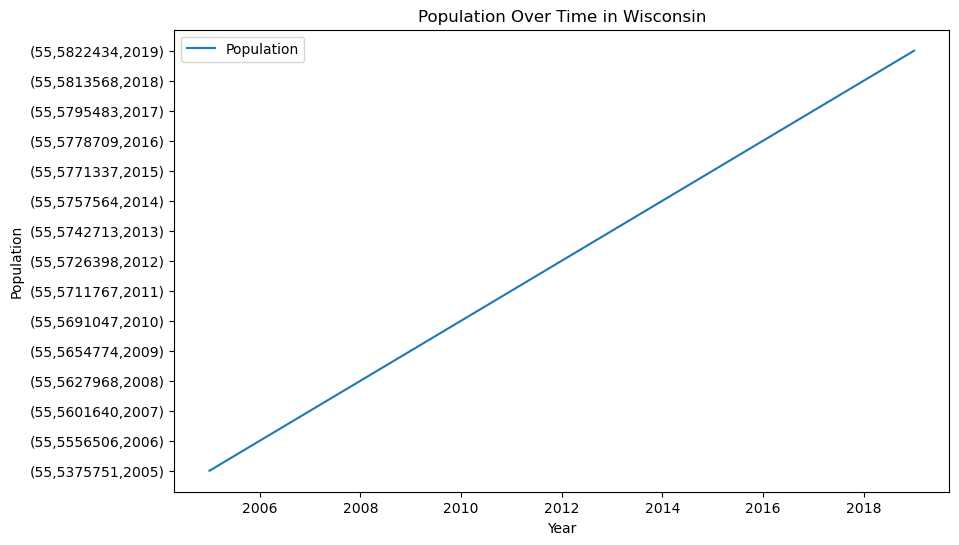

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
# SQL query
query = """
        SELECT 
            year,
            population
        FROM population
        WHERE fips = '55'  
        ORDER BY year
        """

# fetch data into pandas DataFrame
df = pd.read_sql_query(query, conn)
plt.figure(figsize=(10,6))
plt.plot(df['year'], df['population'], label="Population")
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Population Over Time in Wisconsin')
plt.legend()
plt.show()

In [6]:
query_pop = """
            SELECT 
                year,
                population
            FROM population
            WHERE fips = '55'
            ORDER BY year
            """

query_inc = """
            SELECT 
                year,
                income
            FROM income
            WHERE fips = '55'
            ORDER BY year
            """

query_growth = """
               SELECT 
                    year,
                    pop AS population,
                    LAG(pop) OVER (ORDER BY year) AS prev_population,
                    ROUND(
                        ((pop::numeric - LAG(pop) OVER (ORDER BY year)) 
                        / LAG(pop) OVER (ORDER BY year)) * 100, 2
                    ) AS population_percent_change
                FROM population
                WHERE fips = '55'
                ORDER BY year;
               """

# Fetch data in pandas DataFrames
df_pop = pd.read_sql_query(query_pop, conn)
df_inc = pd.read_sql_query(query_inc, conn)
df_growth = pd.read_sql_query(query_growth, conn)

In [7]:
df = pd.merge(pd.merge(df_pop, df_inc, on='year'), df_growth[['year', 'population_percent_change']], on='year')

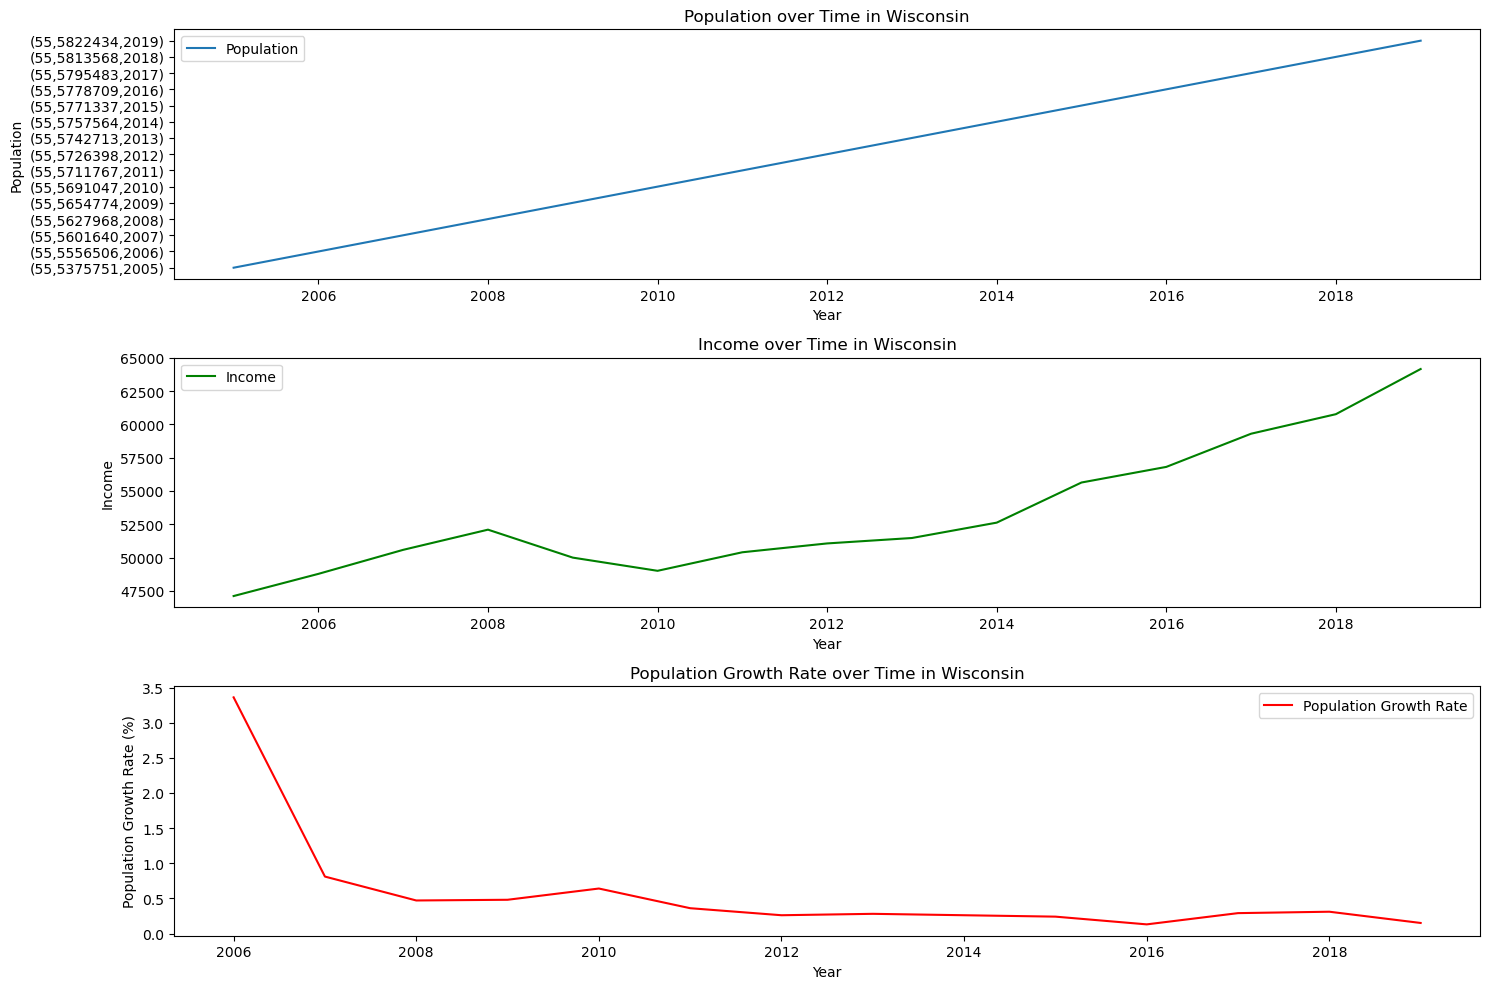

In [8]:
plt.figure(figsize=(15,10))

# Plot population
plt.subplot(3, 1, 1)
plt.plot(df['year'], df['population'], label='Population')
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Population over Time in Wisconsin')
plt.legend()

# Plot income
plt.subplot(3, 1, 2)
plt.plot(df['year'], df['income'], label='Income', color='green')
plt.xlabel('Year')
plt.ylabel('Income')
plt.title('Income over Time in Wisconsin')
plt.legend()

# Plot population growth rate
plt.subplot(3, 1, 3)
plt.plot(df['year'], df['population_percent_change'], label='Population Growth Rate', color='red')
plt.xlabel('Year')
plt.ylabel('Population Growth Rate (%)')
plt.title('Population Growth Rate over Time in Wisconsin')
plt.legend()

# Adjust the subplots layout
plt.tight_layout()
plt.show()

In [9]:
# population growth rate dropped in 2007 and stayed at about the same level. Population 

In [20]:
pip install -U pip setuptools wheel

Note: you may need to restart the kernel to use updated packages.


In [21]:
pip install --only-binary=:all: "tiktoken>=0.7.0"

Note: you may need to restart the kernel to use updated packages.


In [22]:
pip install "jupyter-ai-magics[all]" -q

Note: you may need to restart the kernel to use updated packages.


In [23]:
pip install "jupyter-ai-magics[all]" -q

Note: you may need to restart the kernel to use updated packages.


In [24]:
%%ai gpt4 
here is my sql code, can you give me code that would load it here and visualize it: SELECT 
    n.name AS region_name,
    p.year,
    p.pop AS population,
    i.income
FROM public.population p
JOIN public.income i 
    ON p.fips = i.fips 
   AND p.year = i.year
JOIN public.name n 
    ON p.fips = n.fips
WHERE n.fips = '55'
ORDER BY p.year;

UsageError: Cell magic `%%ai` not found.


In [19]:
query = """
SELECT 
    n.name AS region_name,
    p.year,
    p.pop AS population,
    i.income
FROM public.population p
JOIN public.income i 
    ON p.fips = i.fips 
   AND p.year = i.year
JOIN public.name n 
    ON p.fips = n.fips
WHERE n.fips = '55'
ORDER BY p.year;
"""

# Run the SQL query and load into a pandas DataFrame
df = pd.read_sql(query, conn)

# View the first few rows
df.head()

,region_name,year,population,income
0,Wisconsin,2005,5375751,47105
1,Wisconsin,2006,5556506,48772
2,Wisconsin,2007,5601640,50578
3,Wisconsin,2008,5627968,52094
4,Wisconsin,2009,5654774,49993


In [ ]:
%%ai gpt4 
i need this: Visualization: create a dual-axis chart in Python with Jupyter AI’s help:
o X-axis = year
o Left Y-axis = population (line)
o Right Y-axis = median household income (bar or line, different color)
Title is wisconsin
using this: query = """
SELECT 
    n.name AS region_name,
    p.year,
    p.pop AS population,
    i.income
FROM public.population p
JOIN public.income i 
    ON p.fips = i.fips 
   AND p.year = i.year
JOIN public.name n 
    ON p.fips = n.fips
WHERE n.fips = '55'
ORDER BY p.year;
"""

# Run the SQL query and load into a pandas DataFrame
df = pd.read_sql(query, conn)

# View the first few rows
df.head()

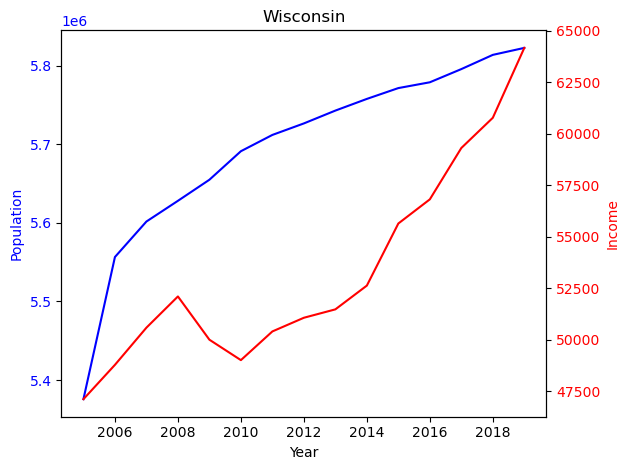

In [26]:
import matplotlib.pyplot as plt

# Create a new figure and add a subplot
fig, ax1 = plt.subplots()

# Create a line plot on ax1 for population, with color blue
ax1.plot(df['year'], df['population'], color='blue')
ax1.set_xlabel('Year')
ax1.set_ylabel('Population', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()

# Create a line plot on ax2 for income, with color red
ax2.plot(df['year'], df['income'], color='red')
ax2.set_ylabel('Income', color='red')  # we already handled the x-label with ax1
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Wisconsin')
# Adjust the plot to make sure everything fits
fig.tight_layout()
plt.show()

Population has a constant increase in Wisconsin, but income decreased in 2008 and then started to increase again in 2010. This is likely because of the economic crash of 2008. The income is rising at a faster rate than population by 2018.

In [ ]:
%%ai gpt4 
here is my sql code, can you give me the python code that would load it here: WITH pop_change AS (
    SELECT 
        year,
        (pop - LAG(pop) OVER (ORDER BY year))::numeric / LAG(pop) OVER (ORDER BY year) * 100 AS pop_percent_change
    FROM public.population
    WHERE fips = '55'
),
income_change AS (
    SELECT 
        year,
        (income - LAG(income) OVER (ORDER BY year))::numeric / LAG(income) OVER (ORDER BY year) * 100 AS income_percent_change
    FROM public.income
    WHERE fips = '55'
)
SELECT 
    p.year,
    ROUND(p.pop_percent_change, 2) AS population_growth,
    ROUND(i.income_percent_change, 2) AS income_growth
FROM pop_change p
JOIN income_change i ON p.year = i.year
ORDER BY p.year;

In [14]:
sql_query = """
WITH pop_change AS (
    SELECT 
        year,
        (pop - LAG(pop) OVER (ORDER BY year))::numeric / LAG(pop) OVER (ORDER BY year) * 100 AS pop_percent_change
    FROM public.population
    WHERE fips = '55'
),
income_change AS (
    SELECT 
        year,
        (income - LAG(income) OVER (ORDER BY year))::numeric / LAG(income) OVER (ORDER BY year) * 100 AS income_percent_change
    FROM public.income
    WHERE fips = '55'
)
SELECT 
    p.year,
    ROUND(p.pop_percent_change, 2) AS population_growth,
    ROUND(i.income_percent_change, 2) AS income_growth
FROM pop_change p
JOIN income_change i ON p.year = i.year
ORDER BY p.year
"""

# Read the SQL query into a DataFrame
df = pd.read_sql(sql_query, conn)

# Show the DataFrame
print(df)

    year  population_growth  income_growth
0   2005                NaN            NaN
1   2006               3.36           3.54
2   2007               0.81           3.70
3   2008               0.47           3.00
4   2009               0.48          -4.03
5   2010               0.64          -1.98
6   2011               0.36           2.84
7   2012               0.26           1.32
8   2013               0.28           0.80
9   2014               0.26           2.24
10  2015               0.24           5.73
11  2016               0.13           2.11
12  2017               0.29           4.39
13  2018               0.31           2.48
14  2019               0.15           5.59


In [15]:
%%ai gpt4 
here is my code for my data, can you visualize it in a chart that would be appropriate and include the name wisconsin in the title

sql_query = """
WITH pop_change AS (
    SELECT 
        year,
        (pop - LAG(pop) OVER (ORDER BY year))::numeric / LAG(pop) OVER (ORDER BY year) * 100 AS pop_percent_change
    FROM public.population
    WHERE fips = '55'
),
income_change AS (
    SELECT 
        year,
        (income - LAG(income) OVER (ORDER BY year))::numeric / LAG(income) OVER (ORDER BY year) * 100 AS income_percent_change
    FROM public.income
    WHERE fips = '55'
)
SELECT 
    p.year,
    ROUND(p.pop_percent_change, 2) AS population_growth,
    ROUND(i.income_percent_change, 2) AS income_growth
FROM pop_change p
JOIN income_change i ON p.year = i.year
ORDER BY p.year
"""

# Read the SQL query into a DataFrame
df = pd.read_sql(sql_query, conn)

UsageError: Cell magic `%%ai` not found.


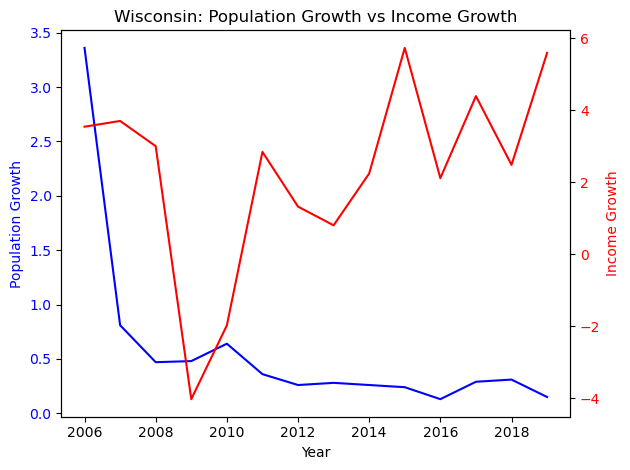

In [16]:
fig, ax1 = plt.subplots()

# Plot Population Growth (Left Y Axis)
ax1.plot(df['year'], df['population_growth'], color='blue', label='Population Growth')
ax1.set_xlabel('Year')  # X-axis label
ax1.set_ylabel('Population Growth', color='blue')  # Left Y-axis label
ax1.tick_params(axis='y', labelcolor='blue')  # Set color of Y-axis ticks to blue

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()

# Plot Income Growth (Right Y Axis)
ax2.plot(df['year'], df['income_growth'], color='red', label='Income Growth')  
ax2.set_ylabel('Income Growth', color='red')  # Right Y-axis label
ax2.tick_params(axis='y', labelcolor='red')  # Set color of Y-axis ticks to red 

# Set title for the graph
plt.title('Wisconsin: Population Growth vs Income Growth')  

# Set layout for better appearance
fig.tight_layout()  

# Show the plot
plt.show()

This graph compares Wisconsin's population growth rate (blue) and its income growth rate (red).Both population growth rate and income growth rate fell in the 2000s. The population growth rate fell in 2007, and the income growth rate fell in 2009. Usually these two values mirror each other, which is true when they both fell in the 2000s, but the income growth rate increased again to the rate it was before by 2014, and is even higher than it was before by 2018, while the population growth rate stayed the same after it fell. This is unusual for a state because the income growth rate and population growth rate usually mirror each other. 